# Data Joining: Data Centers and Political Factors

## DSCI 591 Capstone: Data Center Impact Explorer

* *Jillian Kunze*
* *Andrea MacGregor*
* *Anna Grace*
* *Morgan Murphy*

In the notebook `Dev_ZIP_to_FIPS.ipynb`, we developed a strategy to convert from ZIP code or county/state (how location is represented in the data centers dataset) to FIPS code (how location is represented in the various political datasets). Now, we can implement that strategy to allow us to join data between these various datasets based on location. 


### Adding FIPS to Data Centers Data

The code here is replicated and streamlined from `Dev_ZIP_to_FIPS.ipynb`. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
# Read in ZIP/FIPS dataset from Row Zero
zip_fips_df = pd.read_csv("./Data/Copy of FIPS code lists and location mapping - ZIP to County.csv")

zip_fips_df["Ratio_of_ZIP_Res_in_County"] = zip_fips_df["% of ZIP Residents in County"].str.replace("%", "", regex = True)
zip_fips_df["Ratio_of_ZIP_Res_in_County"] = pd.to_numeric(zip_fips_df["Ratio_of_ZIP_Res_in_County"]) / 100

zip_fips_df["County_and_state"] = zip_fips_df["County"] + ", " + zip_fips_df["State Abbreviation"]

In [3]:
# Read in data center dataset from FracTracker
data_center_df = pd.read_excel("./Data/FracTrackers_Data_Centers_Database.xlsx")

In [4]:
def ZIP_to_FIPS_with_county(input_zip, input_county = None, input_state = None): 
    '''
    Input a zip code, county, and state; output the corresponding FIPS code
    Uses RowZero Zip to County dataset
    If ZIP code corresponds to multiple FIPS code, uses the one with highest proportion of residents 
    '''
    # First, if no zip code is available or it is not represented in the ZIP to FIPS dataset, 
    # try to find the FIPS code based on the county and state name
    if math.isnan(input_zip) or input_zip not in zip_fips_df["ZIP"].unique():
        if (not input_county) or (not input_state): 
            return None
        input_county_state = input_county.strip() + " County, " + str(input_state).strip()
        FIPS_for_input = zip_fips_df[zip_fips_df["County_and_state"] == input_county_state]["County FIPS code"].unique() 
        if len(FIPS_for_input) > 0: 
            return FIPS_for_input[0] # there should always be only one entry in this list, since each county has one FIPS code
        else: 
            return None

    # If ZIP code is available, use it to find FIPS code
    input_zip_df = zip_fips_df[zip_fips_df["ZIP"] == int(input_zip)]
    id_max_pop = input_zip_df["Ratio_of_ZIP_Res_in_County"].idxmax()
    FIPS_for_input_ZIP = input_zip_df.at[id_max_pop, "County FIPS code"]
    return FIPS_for_input_ZIP

In [5]:
data_center_df["fips"] = data_center_df.apply(lambda x: ZIP_to_FIPS_with_county(x["zip"], x["county"], x["state"]), axis = 1)

### Grouping Data Center Data by FIPS 

<mark>TODO: add more to the aggregation</mark>

In [6]:
dc_per_fips = (data_center_df.groupby("fips").size().reset_index(name = "data_center_count"))
dc_per_fips.head()

,fips,data_center_count
0,1071.0,1
1,1073.0,3
2,1089.0,2
3,1101.0,1
4,1103.0,1


### Pre-processing for NANDA

I'll first look at the NANDA dataset, since I think that will require the least pre-processing. 

<mark>Add more descriptions below</mark>

In [20]:
nanda_df = pd.read_csv("./Data/ICPSR_38506/DS0001/38506-0001-Data.tsv", sep = "\t")
nanda_df.head()

,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001,2000,,,,,,,4942,11993,,,.2918216586113,.7081783413887,,,,
1,1001,2002,,,,,,,,,3819,10687,,,.2632703781128,.7367296218872,,
2,1001,2004,28100,20119,34420,.816385805607,.584514796734,.715978622437,4758,15196,3960,15728,.2384484261274,.7615515589714,.2011377513409,.7988622784615,,
3,1001,2006,29724,0,36140,.822468161583,0,0,,,,,,,,,.2582950294018,.7417049407959
4,1001,2008,33536,23714,39580,.847296595573,.599141001701,.707120716572,6093,17403,5316,17941,.2593207359314,.7406792640686,.2285763472319,.771423637867,.2423373311758,.757662653923


I'll only use the results for 2022, since that's the most recent year recorded in NANDA.

In [21]:
nanda_df_22 = nanda_df[nanda_df["YEAR"] == 2022][["STCOFIPS10", "REG_VOTERS", "VOTER_TURNOUT_PCT", 
                                                  "REG_VOTER_TURNOUT_PCT", "PARTISAN_INDEX_DEM", "PARTISAN_INDEX_REP"]]
nanda_df_22.head()

,STCOFIPS10,REG_VOTERS,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
11,1001,43488,.397021889687,.410779982805,.2544515430927,.745548427105
23,1003,189028,.400007605553,.389418512583,.2039499729872,.7960500121117
35,1005,17270,.333924770355,.381412863731,.4373672306538,.5626327395439
47,1007,14741,.336906939745,.400786906481,.196561858058,.8034381270409
59,1009,41794,.366510659456,.399124264717,.089328661561,.9106713533401


In [22]:
nanda_df_22.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3108 entries, 11 to 35277
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   STCOFIPS10             3108 non-null   int64 
 1   REG_VOTERS             3108 non-null   object
 2   VOTER_TURNOUT_PCT      3108 non-null   object
 3   REG_VOTER_TURNOUT_PCT  3108 non-null   object
 4   PARTISAN_INDEX_DEM     3108 non-null   object
 5   PARTISAN_INDEX_REP     3108 non-null   object
dtypes: int64(1), object(5)
memory usage: 170.0+ KB


In [23]:
vote_info_cols = ["REG_VOTERS", "VOTER_TURNOUT_PCT", "REG_VOTER_TURNOUT_PCT", "PARTISAN_INDEX_DEM", "PARTISAN_INDEX_REP"]
nanda_df_22[vote_info_cols] = nanda_df_22[vote_info_cols].apply(pd.to_numeric, errors = "coerce")

Per the [NANDA docs](https://www.icpsr.umich.edu/web/ICPSR/studies/38506/datasets/0001/variables/STCOFIPS10?archive=icpsr), `STCOFIPS10` represents the county FIPS code. I'll rename the column to match what I have for the data centers to make merging easier.

In [24]:
# Rename FIPS column to make merge more straightforward
nanda_df_22 = nanda_df_22.rename(columns = {"STCOFIPS10": "fips"})

In [25]:
nanda_df_22.head()

,fips,REG_VOTERS,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
11,1001,43488.0,0.397022,0.410780,0.254452,0.745548
23,1003,189028.0,0.400008,0.389419,0.203950,0.796050
35,1005,17270.0,0.333925,0.381413,0.437367,0.562633
47,1007,14741.0,0.336907,0.400787,0.196562,0.803438
59,1009,41794.0,0.366511,0.399124,0.089329,0.910671


### Join FracTrackers Data Centers with NANDA

<mark>Note why I'm using an outer join here</mark>

<mark>Note that before I switched to same column name `fips` for both in the merge, there were 3 FIPS from the data centers data that did not appear in the NANDA data, but I looked them up and they were real</mark>

<mark>Potentiall add suffix, depending on whether I want to create one huge datasets or keep it split out?</mark>

In [26]:
dc_nanda_df = dc_per_fips.merge(nanda_df_22, how = "outer", on = "fips")
print(dc_nanda_df.shape)
dc_nanda_df.head()

(3111, 7)


,fips,data_center_count,REG_VOTERS,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001.0,NaN,43488.0,0.397022,0.410780,0.254452,0.745548
1,1003.0,NaN,189028.0,0.400008,0.389419,0.203950,0.796050
2,1005.0,NaN,17270.0,0.333925,0.381413,0.437367,0.562633
3,1007.0,NaN,14741.0,0.336907,0.400787,0.196562,0.803438
4,1009.0,NaN,41794.0,0.366511,0.399124,0.089329,0.910671


In [15]:
dc_nanda_df.isnull().sum()

fips                        0
data_center_count        2576
REG_VOTERS                  8
VOTER_TURNOUT_PCT           8
REG_VOTER_TURNOUT_PCT       9
PARTISAN_INDEX_DEM          6
PARTISAN_INDEX_REP          6
dtype: int64

There are lots of cases where the data center count is null for a FIPS code, then the count should be 0, since the FracTrackers dataset did not record any data centers for that location. 

In [16]:
dc_nanda_df["data_center_count"] = dc_nanda_df["data_center_count"].fillna(0)
dc_nanda_df.head()

,fips,data_center_count,REG_VOTERS,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001.0,0.0,43488.0,0.397022,0.410780,0.254452,0.745548
1,1003.0,0.0,189028.0,0.400008,0.389419,0.203950,0.796050
2,1005.0,0.0,17270.0,0.333925,0.381413,0.437367,0.562633
3,1007.0,0.0,14741.0,0.336907,0.400787,0.196562,0.803438
4,1009.0,0.0,41794.0,0.366511,0.399124,0.089329,0.910671


In [14]:
dc_nanda_df["data_center_count"].value_counts()

data_center_count
0.0      2576
1.0       326
2.0        85
3.0        41
4.0        25
5.0        12
6.0        10
7.0         6
11.0        5
8.0         4
12.0        4
13.0        3
20.0        2
16.0        1
25.0        1
59.0        1
15.0        1
26.0        1
17.0        1
29.0        1
18.0        1
190.0       1
68.0        1
21.0        1
9.0         1
Name: count, dtype: int64

<mark>Check/improve aggregation below</mark>

In [17]:
dc_nanda_df_grouped = dc_nanda_df.groupby("data_center_count")[vote_info_cols].mean().reset_index()
dc_nanda_df_grouped.head()

,data_center_count,REG_VOTERS,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,0.0,40579.006610,0.460884,0.501051,0.330098,0.669902
1,1.0,128252.941176,0.436015,0.491655,0.401997,0.598003
2,2.0,164552.380952,0.429536,0.497979,0.436172,0.563828
3,3.0,489987.658537,0.419030,0.509611,0.523411,0.476589
4,4.0,416853.240000,0.471665,0.545387,0.505360,0.494640


<mark>improve this plot - account for how some are aggregating a ton of places and some are for just one location (error bars, violin plot).</mark>

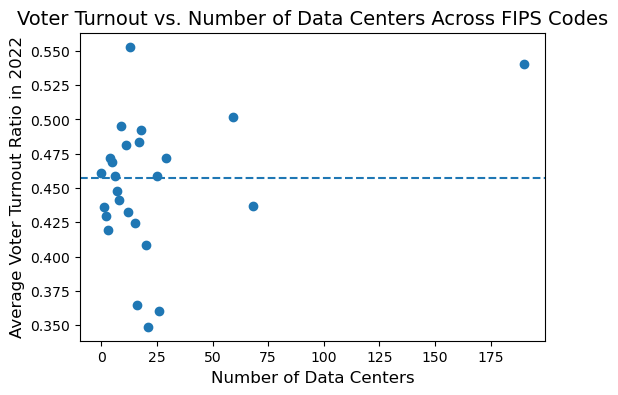

In [18]:
plt.figure(figsize = (6,4))
plt.scatter(dc_nanda_df_grouped["data_center_count"], dc_nanda_df_grouped["VOTER_TURNOUT_PCT"])

avg_turnout = dc_nanda_df["VOTER_TURNOUT_PCT"].mean()
plt.axhline(avg_turnout, ls = "dashed")

plt.title("Voter Turnout vs. Number of Data Centers Across FIPS Codes", fontsize = 14)
plt.ylabel("Average Voter Turnout Ratio in 2022", fontsize = 12)
plt.xlabel("Number of Data Centers", fontsize = 12)
#plt.xlim([-1, 75])
plt.show()

<mark>Possible improvements to this graph:</mark>
* Violin plot
* Group counties by number of data centers (1-5, 6-10, etc.)
* Count number of counties with data centers that are above vs. below average voter turnout

In [ ]:
# Make violin plot 
# http://datavizcatalogue.com/methods/violin_plot.html
# https://seaborn.pydata.org/generated/seaborn.violinplot.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.violinplot.html
# https://matplotlib.org/stable/gallery/statistics/violinplot.html

### Pre-processing for American Local Government Elections Database

<mark>Add description</mark>

In [7]:
local_df = pd.read_csv("./Data/2021_local_politics/ledb_candidatelevel.csv")
local_df.head()

,ledb_candid,full_name,firstname,lastname,fips,geo_name,state_abb,office_consolidated,year,month,...,prob_female,prob_male,gender_est,prob_black,prob_white,prob_hispanic,prob_asian,prob_other,race_est,ballotpedia_url
0,59965,gil garcetti,gil,garcetti,06037,los angeles,CA,Prosecutor,1992,11.0,...,0.03,0.97,M,0.02,0.83,0.14,0.01,0.0,caucasian,NaN
1,59966,george gascon,george,gascon,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.00,1.00,M,0.14,0.72,0.10,0.03,0.0,caucasian,NaN
2,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
3,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2012,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
4,7904,kim foxx,kim,foxx,17031,cook,IL,Prosecutor,2016,11.0,...,1.00,0.00,F,0.93,0.06,0.00,0.00,0.0,black,NaN


In [20]:
local_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126599 entries, 0 to 126598
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ledb_candid          126599 non-null  int64  
 1   full_name            126599 non-null  object 
 2   firstname            125840 non-null  object 
 3   lastname             126562 non-null  object 
 4   fips                 126599 non-null  object 
 5   geo_name             124433 non-null  object 
 6   state_abb            126599 non-null  object 
 7   office_consolidated  126599 non-null  object 
 8   year                 126599 non-null  int64  
 9   month                121584 non-null  float64
 10  district             124998 non-null  object 
 11  contest              126599 non-null  object 
 12  votes                126599 non-null  float64
 13  vote_share           126592 non-null  float64
 14  n_winners            126599 non-null  int64  
 15  winner           

<mark>For now, will just filter out where FIPS is none - could also try to find FIPS based on county + state</mark>

In [8]:
# Only want candidates who won their elections
# and only keep around the rows that will be useful
useful_rows = ['fips', 'geo_name', 'state_abb', 'office_consolidated', 'year', 'winner', 'incumbent', 'prob_democrat', 'prob_republican', 'pid_est']
local_winners_df = local_df[local_df["winner"] == "win"][useful_rows]

# Set FIPS column to numeric
local_winners_df["fips"] = local_winners_df["fips"].apply(pd.to_numeric, errors = "coerce")

# Do not want to include where FIPS is null, since I need that to join 
local_winners_df = local_winners_df.dropna(subset = ["fips"])

In [9]:
local_winners_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62621 entries, 0 to 126598
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fips                 62621 non-null  float64
 1   geo_name             62587 non-null  object 
 2   state_abb            62621 non-null  object 
 3   office_consolidated  62621 non-null  object 
 4   year                 62621 non-null  int64  
 5   winner               62621 non-null  object 
 6   incumbent            50772 non-null  float64
 7   prob_democrat        58483 non-null  float64
 8   prob_republican      58483 non-null  float64
 9   pid_est              58483 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 5.3+ MB


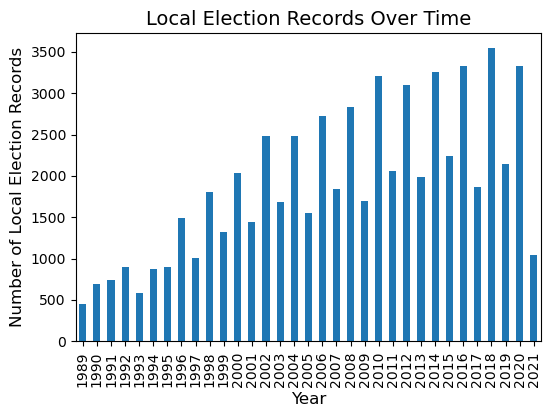

In [10]:
# Let's see what years are available, and how much data there is for each
# https://stackoverflow.com/questions/49059956/pandas-plot-value-counts-barplot-in-descending-manner
plt.figure(figsize = (6,4))

local_winners_df["year"].value_counts().sort_index().plot(kind = "bar")

plt.title("Local Election Records Over Time", fontsize = 14)
plt.ylabel("Number of Local Election Records", fontsize = 12)
plt.xlabel("Year", fontsize = 12)
plt.show()

In [11]:
# how much coverage do we have in 2020, one of the most recent years shown?
print("Unique FIPS codes in 2020:", local_winners_df[local_winners_df["year"] == 2020]["fips"].nunique())
print("Unique FIPS codes overall:", local_winners_df["fips"].nunique())
print("Unique FIPS codes for data centers:", data_center_df["fips"].nunique())

Unique FIPS codes in 2020: 913
Unique FIPS codes overall: 1746
Unique FIPS codes for data centers: 535


In [12]:
set_dc_fips = set(data_center_df["fips"])
set_local_2020_fips = set(local_winners_df[local_winners_df["year"] == 2020]["fips"])
set_local_fips = set(local_winners_df["fips"])
print("Number of data centers FIPS covered by local elections dataset for 2020:", len(set_dc_fips.intersection(set_local_2020_fips)))
print("Number of data centers FIPS covered by local elections dataset overall:", len(set_dc_fips.intersection(set_local_fips)))

Number of data centers FIPS covered by local elections dataset for 2020: 224
Number of data centers FIPS covered by local elections dataset overall: 372


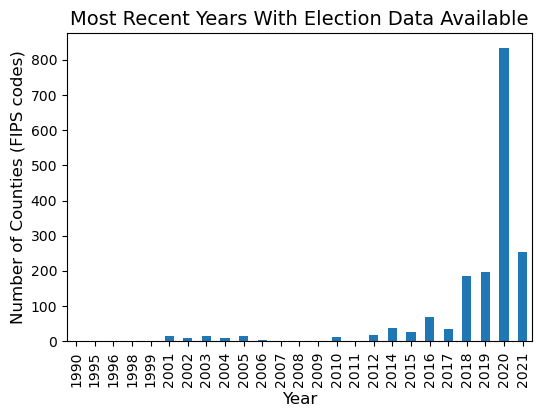

In [13]:
# Find most recent election info for each FIPS code 
# https://stackoverflow.com/questions/43899886/how-do-i-just-keep-the-rows-with-the-maximum-value-in-a-column-for-items-of-the
plt.figure(figsize = (6,4))

local_df_recent_years = local_winners_df.loc[local_winners_df.groupby("fips")["year"].idxmax()]
local_df_recent_years["year"].value_counts().sort_index().plot(kind = "bar")

plt.title("Most Recent Years With Election Data Available", fontsize = 14)
plt.ylabel("Number of Counties (FIPS codes)", fontsize = 12)
plt.xlabel("Year", fontsize = 12)
plt.show()

<mark>So, it could benefit me to look further back than 2020</mark>
* May also want to try cleaning the FIPS code from the local elections dataset a bit more, since I'm definitely missing some bc of how not clean it is 

<mark>TODO: overall goal is to find out over last n years, what portion of elected officials have been D vs. R</mark>

In [63]:
local_winners_df["fips"]

0          6037.0
1          6037.0
3          6037.0
4         17031.0
5         17031.0
           ...   
126592    29095.0
126594    12109.0
126596    36029.0
126597    42069.0
126598    42069.0
Name: fips, Length: 62621, dtype: float64

### Join FracTrackers Data Centers with American Local Government Elections Database

In [27]:
# Try merge w/ data centers data, and find out how many have what number of election results associated with them
merge_dc_local = dc_per_fips.merge(local_winners_df, how = "outer", on = "fips")

merge_dc_local["data_center_count"] = merge_dc_local["data_center_count"].fillna(0) # same strat as before 

print(merge_dc_local.shape)
merge_dc_local.head()

(62784, 11)


,fips,data_center_count,geo_name,state_abb,office_consolidated,year,winner,incumbent,prob_democrat,prob_republican,pid_est
0,1001.0,0.0,autauga,AL,Sheriff,2018.0,win,NaN,0.0,1.0,R
1,1003.0,0.0,baldwin,AL,Sheriff,2018.0,win,1.0,0.0,1.0,R
2,1003.0,0.0,baldwin,AL,County Legislature,2018.0,win,0.0,0.0,1.0,R
3,1003.0,0.0,baldwin,AL,County Legislature,2018.0,win,1.0,0.0,1.0,R
4,1003.0,0.0,baldwin,AL,County Legislature,2018.0,win,0.0,0.0,1.0,R


In [15]:
merge_dc_local.isnull().sum()

fips                       0
data_center_count      46830
geo_name                 197
state_abb                163
office_consolidated      163
year                     163
winner                   163
incumbent              12012
prob_democrat           4301
prob_republican         4301
pid_est                 4301
dtype: int64

<mark>TODO: make vis showing election records available for data center FIPS specifically</mark>